<a href="https://colab.research.google.com/github/panzehui0206/AI4S-365days/blob/main/%E7%AC%AC%E4%BA%8C%E7%AB%A0%20%E7%94%9F%E5%91%BD%E7%A7%91%E5%AD%A6%E7%9A%84%E2%80%9C%E8%87%AA%E7%84%B6%E8%AF%AD%E8%A8%80%E2%80%9D%E2%80%94%E2%80%94%E5%BA%8F%E5%88%97%E5%A4%84%E7%90%86/Note1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  **2026.4.12**

  开始学习吧！

In [2]:
# =============================================
# Cell 1：环境准备 + 生成模拟 FASTA 和 FASTQ 文件
# =============================================
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install biopython -q

from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
import random
import matplotlib.pyplot as plt

# 设置随机种子
random.seed(42)

# ------------------ 生成模拟 FASTA 文件 ------------------
# 模拟 10 条不同长度的 DNA 序列（代表转录本/基因）
fasta_records = []
for i in range(1, 11):
    seq_len = random.randint(200, 1500)  # 长度 200~1500 bp
    seq = Seq("".join(random.choices("ATGC", k=seq_len)))
    record = SeqRecord(seq, id=f"transcript_{i}", description="")
    fasta_records.append(record)

# 写入本地 FASTA 文件
fasta_file = "transcripts.fasta"
with open(fasta_file, "w") as f:
    SeqIO.write(fasta_records, f, "fasta")

print(f"✅ 已生成模拟 FASTA 文件: {fasta_file} (10 条序列)")

# ------------------ 生成模拟 FASTQ 文件 ------------------
# 模拟 1000 条短读长（代表 Illumina 测序 reads）
fastq_records = []
for i in range(1, 1001):
    seq_len = random.randint(50, 150)  # 读长 50~150 bp
    seq = Seq("".join(random.choices("ATGC", k=seq_len)))
    # 质量分数：模拟测序质量从 5' 到 3' 逐渐下降的趋势
    # Illumina 质量值通常用 Phred+33 编码，范围约 0~40
    qual_scores = [max(10, 40 - int(0.2 * pos) + random.randint(-5, 5)) for pos in range(seq_len)]
    qual_str = "".join(chr(q + 33) for q in qual_scores)  # 转为 ASCII 字符
    record = SeqRecord(seq, id=f"read_{i}", description="", letter_annotations={"phred_quality": qual_scores})
    # 注意：SeqIO 写 FASTQ 需要把质量分数存在 letter_annotations 或直接用字符串
    record.letter_annotations = {}
    fastq_records.append((record, qual_str))

# 手动写 FASTQ（因为 SeqIO.write 需要特定格式）
fastq_file = "reads.fastq"
with open(fastq_file, "w") as f:
    for record, qual_str in fastq_records:
        f.write(f"@{record.id}\n{str(record.seq)}\n+\n{qual_str}\n")

print(f"✅ 已生成模拟 FASTQ 文件: {fastq_file} (1000 条 reads)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.0 MB/s eta 0:00:00
✅ 已生成模拟 FASTA 文件: transcripts.fasta (10 条序列)
✅ 已生成模拟 FASTQ 文件: reads.fastq (1000 条 reads)


测序仪或数据库里的 **DNA/RNA/蛋白质序列**，本质上就是**一串字母**（A、T、G、C 或氨基酸单字母符号）。**FASTA** 是一种用**纯文本文件**来存储这些序列的格式规范，它规定了如何把“**序列的名字**”和“**序列的内容**”组织在一起，让计算机程序能准确识别。

**>** 是 **FASTA** 格式的“标识符行”的固定开头符号。

**FASTQ** 是测序仪下机数据的原始格式，每 **4** 行为一个 **read**：@ID（标识符行）、序列行、+（分隔符行）、质量字符串（质量行）。

序列行和质量行的长度严格相等，质量行的字符是**ASCII** 字符，需要解码才能得到真实的 Phred 质量值。

**质量值**是一个数字，代表测序仪对某个碱基判读的“**自信程度**”。

质量值用 Phred 分数 表示：Q = -10 log10(错误率)。例如 Q30 表示错误率 0.1%。这里模拟了质量沿读长方向逐渐下降的趋势，符合真实测序特征。

真实 Illumina 测序过程： **DNA** 链被固定在芯片上，每合成一个碱基就拍一张荧光照。随着反应循环增加，合成试剂逐渐耗尽、酶活性下降、荧光信号衰减，导致越往后读，判读越不准。

transcript_1: 长度 =  428 bp, GC含量 = 50.00%
transcript_2: 长度 =  418 bp, GC含量 = 46.41%
transcript_3: 长度 = 1199 bp, GC含量 = 51.79%
transcript_4: 长度 =  231 bp, GC含量 = 50.65%
transcript_5: 长度 =  774 bp, GC含量 = 49.74%
transcript_6: 长度 =  956 bp, GC含量 = 53.45%
transcript_7: 长度 = 1187 bp, GC含量 = 49.20%
transcript_8: 长度 = 1091 bp, GC含量 = 49.59%
transcript_9: 长度 =  357 bp, GC含量 = 54.34%
transcript_10: 长度 =  981 bp, GC含量 = 51.58%


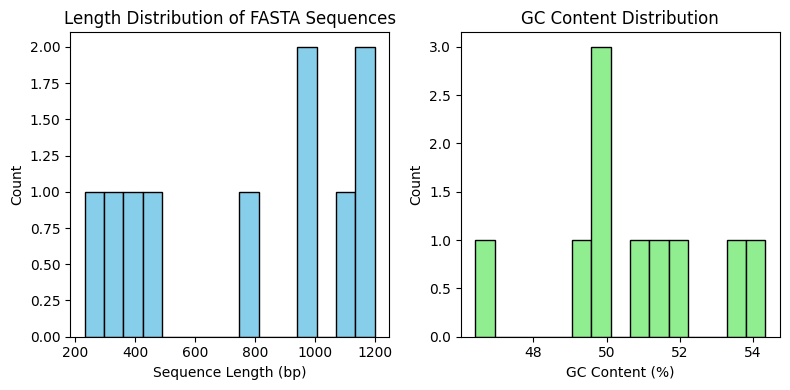

In [3]:
# =============================================
# Cell 2：用 SeqIO.parse 批量处理 FASTA
# =============================================
# 创建两个空列表，储存每条序列的长度和GC含量百分比
lengths = []
gc_contents = []

# SeqIO.parse(文件名, 格式) 是 Biopython 读取多序列文件的标准迭代器。
# 它不会一次性把所有序列读入内存，而是一条一条地生成 SeqRecord 对象。当有一个 10 GB 的宏基因组 FASTA 文件时，这种方式能避免内存爆炸。
for record in SeqIO.parse(fasta_file, "fasta"):
    seq = record.seq
    length = len(seq)
    # seq.count("G") 统计该序列中鸟嘌呤 G 的出现次数；seq.count("C") 统计胞嘧啶 C 的次数。
    gc = 100 * (seq.count("G") + seq.count("C")) / length
    lengths.append(length)
    gc_contents.append(gc)
    print(f"{record.id}: 长度 = {length:4d} bp, GC含量 = {gc:.2f}%")

# 绘制长度分布直方图
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.hist(lengths, bins=15, color='skyblue', edgecolor='black')
plt.xlabel('Sequence Length (bp)')
plt.ylabel('Count')
plt.title('Length Distribution of FASTA Sequences')

# 绘制 GC 含量分布直方图
plt.subplot(1, 2, 2)
plt.hist(gc_contents, bins=15, color='lightgreen', edgecolor='black')
plt.xlabel('GC Content (%)')
plt.ylabel('Count')
plt.title('GC Content Distribution')
plt.tight_layout()
plt.show()

长度分布直方图意义：对于转录组或基因集，长度应呈连续分布，没有异常的尖峰或截断。

GC 含量分布直方图意义：对于单一物种，GC 含量通常呈单峰正态分布，峰值为该物种基因组平均 GC%。

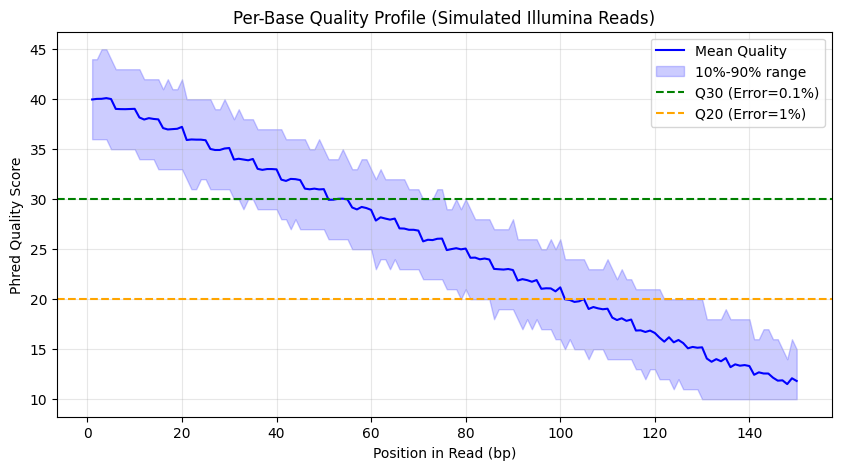

📊 总碱基数: 100705
📊 平均质量: 29.58
📊 Q30 以上碱基比例: 53.74%


In [4]:
# =============================================
# Cell 3：解析 FASTQ 并统计质量分数
# =============================================
# 用于存储每个碱基位置的质量值列表（按读长对齐）
qual_by_position = []  # 每个元素是该位置所有 reads 的质量列表
read_lengths = []

# 第一遍遍历：收集所有质量分数
all_quals = []
for record in SeqIO.parse(fastq_file, "fastq"):
    quals = record.letter_annotations["phred_quality"]
    all_quals.append(quals)
    read_lengths.append(len(quals))

# 因为测序 reads 可能长度不一，需要按最长的那条来创建对应数量的“位置桶”。
max_len = max(read_lengths)

# 初始化位置质量列表
qual_by_position = [[] for _ in range(max_len)]
for quals in all_quals:
    for pos, q in enumerate(quals):
        qual_by_position[pos].append(q)

# 计算每个位置的平均质量、第10百分位数、第90百分位数
mean_quals = [sum(pos_q)/len(pos_q) for pos_q in qual_by_position]
p10_quals = [sorted(pos_q)[len(pos_q)//10] for pos_q in qual_by_position]
p90_quals = [sorted(pos_q)[9*len(pos_q)//10] for pos_q in qual_by_position]

# 绘制质量箱线图（简化版：用均值+百分位范围）
plt.figure(figsize=(10, 5))
plt.plot(range(1, max_len+1), mean_quals, color='blue', label='Mean Quality')
plt.fill_between(range(1, max_len+1), p10_quals, p90_quals, color='blue', alpha=0.2, label='10%-90% range')
plt.axhline(y=30, color='green', linestyle='--', label='Q30 (Error=0.1%)')
plt.axhline(y=20, color='orange', linestyle='--', label='Q20 (Error=1%)')
plt.xlabel('Position in Read (bp)')
plt.ylabel('Phred Quality Score')
plt.title('Per-Base Quality Profile (Simulated Illumina Reads)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 打印整体质量摘要
all_qual_values = [q for quals in all_quals for q in quals]
print(f"📊 总碱基数: {len(all_qual_values)}")
print(f"📊 平均质量: {sum(all_qual_values)/len(all_qual_values):.2f}")
print(f"📊 Q30 以上碱基比例: {100 * sum(q >= 30 for q in all_qual_values) / len(all_qual_values):.2f}%")

这张图是**测序数据质控**的核心图表，它画的是测序仪在每个碱基位置上的“**自信程度**”随读长的变化。

这张图帮助判断测序是否成功没如果下游分析对剪辑准确性要求很高，能够帮助判断质量修剪的部分，帮助判断文库整体质量如何（蓝色区域越窄越好）。

In [5]:
# =============================================
# Cell 4：根据质量筛选 reads
# =============================================
# 定义筛选标准：整条 read 平均质量 >= 25
high_qual_reads = []
low_qual_reads = []

for record in SeqIO.parse(fastq_file, "fastq"):
    quals = record.letter_annotations["phred_quality"]
    avg_qual = sum(quals) / len(quals)
    if avg_qual >= 25:
        high_qual_reads.append(record)
    else:
        low_qual_reads.append(record)

print(f"✅ 高质量 reads (平均 Q>=25): {len(high_qual_reads)} 条")
print(f"❌ 低质量 reads (平均 Q<25): {len(low_qual_reads)} 条")

# 可选：将高质量 reads 写入新的 FASTQ 文件
output_fastq = "high_qual_reads.fastq"
with open(output_fastq, "w") as f:
    SeqIO.write(high_qual_reads, f, "fastq")
print(f"💾 已保存高质量 reads 到: {output_fastq}")

✅ 高质量 reads (平均 Q>=25): 1000 条
❌ 低质量 reads (平均 Q<25): 0 条
💾 已保存高质量 reads 到: high_qual_reads.fastq


测序仪下机 **FASTQ**
      
画**逐位点质量图** → 发现 3' 端质量下降
       

**修剪**切掉每条 read 末尾 Q <20 的部分，丢弃平均质量 < Q25 的整条 read
       
       
高质量 **FASTQ** → 进入比对、定量、变异检测

学了些什么呢？

✅FASTA/FASTQ 格式的底层结构

✅用 SeqIO 批量解析序列文件

✅绘制长度和 GC 分布直方图

✅解析 Phred 质量分数，画逐位点质量图

✅根据质量指标筛选 reads